**The objective of this is to predict carbon intensity from the generation mix.**

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("../data/df_fuel_ckan.csv")

In [5]:
features = [
    "GAS",
    "COAL",
    "NUCLEAR",
    "WIND",
    "SOLAR",
    "HYDRO",
    "IMPORTS",
    "BIOMASS"
]

X = df[features]
y = df["CARBON_INTENSITY"]

In [6]:
df.head()

,DATETIME,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
0,2009-01-01T00:00:00,8367.0,15037.0,7099.0,248.0,62.0,246,2518.0,0.0,0.0,...,7.5,0.0,0.0,0.0,0.0,100.0,22.8,24.5,1.7,69.7
1,2009-01-01T00:30:00,8495.0,15095.0,7088.0,229.0,57.0,245,2495.0,0.0,0.0,...,7.4,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.6,70.0
2,2009-01-01T01:00:00,8471.0,15088.0,7074.0,207.0,52.0,246,2465.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.2,1.5,70.1
3,2009-01-01T01:30:00,8318.0,15035.0,7064.0,191.0,48.0,246,2439.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.5,70.0
4,2009-01-01T02:00:00,8295.0,15005.0,7052.0,175.0,44.0,246,2363.0,0.0,0.0,...,7.1,0.0,0.0,0.0,0.0,100.0,22.7,24.3,1.4,70.2


In [7]:
df.shape

(303389, 34)

In [16]:
df.head()

,DATETIME,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,...,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc,YEAR,MONTH,DAY,HOUR
0,2009-01-01 00:00:00,8367.0,15037.0,7099.0,248.0,62.0,246,2518.0,0.0,0.0,...,0.0,100.0,22.8,24.5,1.7,69.7,2009,1,1,0
1,2009-01-01 00:30:00,8495.0,15095.0,7088.0,229.0,57.0,245,2495.0,0.0,0.0,...,0.0,100.0,22.6,24.3,1.6,70.0,2009,1,1,0
2,2009-01-01 01:00:00,8471.0,15088.0,7074.0,207.0,52.0,246,2465.0,0.0,0.0,...,0.0,100.0,22.6,24.2,1.5,70.1,2009,1,1,1
3,2009-01-01 01:30:00,8318.0,15035.0,7064.0,191.0,48.0,246,2439.0,0.0,0.0,...,0.0,100.0,22.6,24.3,1.5,70.0,2009,1,1,1
4,2009-01-01 02:00:00,8295.0,15005.0,7052.0,175.0,44.0,246,2363.0,0.0,0.0,...,0.0,100.0,22.7,24.3,1.4,70.2,2009,1,1,2


In [9]:
df["DATETIME"] = pd.to_datetime(df["DATETIME"])

In [10]:
df["YEAR"] = df["DATETIME"].dt.year
df["MONTH"] = df["DATETIME"].dt.month
df["DAY"] = df["DATETIME"].dt.day
df["HOUR"] = df["DATETIME"].dt.hour

In [17]:
df.isna().sum().sort_values(ascending=False)

DATETIME            0
STORAGE_perc        0
WIND_perc           0
WIND_EMB_perc       0
HYDRO_perc          0
IMPORTS_perc        0
BIOMASS_perc        0
OTHER_perc          0
SOLAR_perc          0
GENERATION_perc     0
GAS                 0
LOW_CARBON_perc     0
ZERO_CARBON_perc    0
RENEWABLE_perc      0
FOSSIL_perc         0
YEAR                0
MONTH               0
DAY                 0
NUCLEAR_perc        0
COAL_perc           0
GAS_perc            0
FOSSIL              0
COAL                0
NUCLEAR             0
WIND                0
WIND_EMB            0
HYDRO               0
IMPORTS             0
BIOMASS             0
OTHER               0
SOLAR               0
STORAGE             0
GENERATION          0
CARBON_INTENSITY    0
LOW_CARBON          0
ZERO_CARBON         0
RENEWABLE           0
HOUR                0
dtype: int64

Define Features and Target

In [11]:
y = df["CARBON_INTENSITY"]

In [12]:
features = [
    "GAS",
    "COAL",
    "NUCLEAR",
    "WIND",
    "SOLAR",
    "HYDRO",
    "IMPORTS",
    "BIOMASS",
    "YEAR",
    "MONTH",
    "HOUR"
]

X = df[features]

In [22]:
df[features + ["CARBON_INTENSITY"]].corr()["CARBON_INTENSITY"].sort_values()

YEAR               -0.855738
WIND               -0.705107
BIOMASS            -0.669095
IMPORTS            -0.537530
SOLAR              -0.358790
MONTH              -0.030366
HYDRO               0.042113
HOUR                0.068974
GAS                 0.366693
NUCLEAR             0.580563
COAL                0.925227
CARBON_INTENSITY    1.000000
Name: CARBON_INTENSITY, dtype: float64

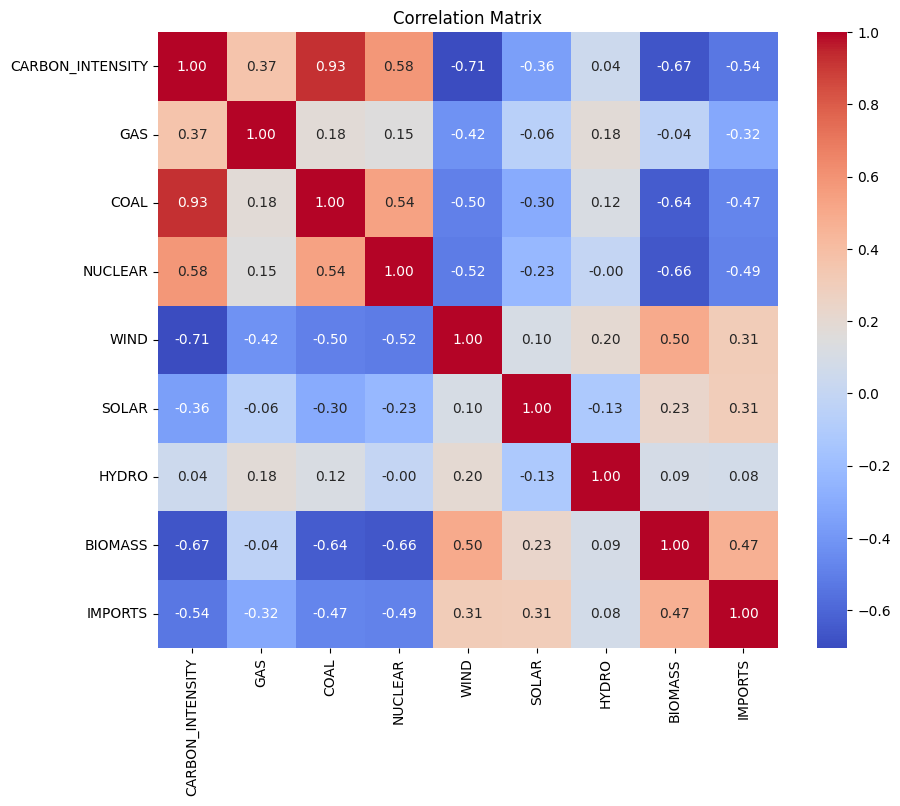

In [23]:
corr_cols = [
    "CARBON_INTENSITY",
    "GAS",
    "COAL",
    "NUCLEAR",
    "WIND",
    "SOLAR",
    "HYDRO",
    "BIOMASS",
    "IMPORTS"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

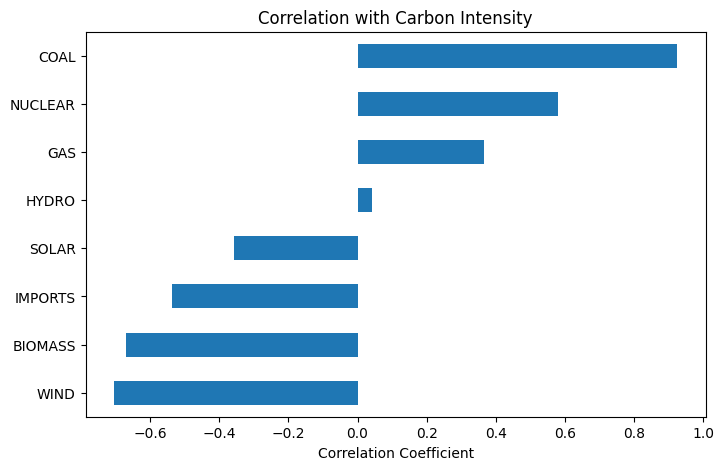

In [24]:
corr_target = (
    df[corr_cols]
    .corr()["CARBON_INTENSITY"]
    .drop("CARBON_INTENSITY")
    .sort_values()
)

plt.figure(figsize=(8,5))

corr_target.plot(
    kind="barh"
)

plt.title("Correlation with Carbon Intensity")
plt.xlabel("Correlation Coefficient")

plt.show()

Time-Based Train-Test Split

In [13]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [18]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 242711
Testing rows: 60678


In [14]:
print(X_train.shape)
print(X_test.shape)

(242711, 11)
(60678, 11)


Baseline Model

In [15]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

In [19]:


print("Baseline MAE:",
      mean_absolute_error(y_test, baseline_pred))

print("Baseline R²:",
      r2_score(y_test, baseline_pred))

Baseline MAE: 192.31646727933582
Baseline R²: -9.536552767776211


Random Forest

In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [25]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("RF MAE:", rf_mae)
print("RF RMSE:", rf_rmse)
print("RF R²:", rf_r2)

RF MAE: 10.552471406440555
RF RMSE: 13.711893019263465
RF R²: 0.9515210390334164


Gradient Boosting

In [21]:


gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [26]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("GB MAE:", gb_mae)
print("GB RMSE:", gb_rmse)
print("GB R²:", gb_r2)

GB MAE: 13.724540705266364
GB RMSE: 17.58370040073948
GB R²: 0.9202778464968923


In [27]:
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "Gradient Boosting"],
    "MAE": [
        192.32,
        rf_mae,
        gb_mae
    ],
    "R2": [
        -9.54,
        rf_r2,
        gb_r2
    ]
})

results

,Model,MAE,R2
0,Baseline,192.320000,-9.540000
1,Random Forest,10.552471,0.951521
2,Gradient Boosting,13.724541,0.920278


The Random Forest model achieved the strongest performance, with an MAE of 10.55 and an R² of 0.952. This indicates that electricity generation sources are highly predictive of carbon intensity. Both machine learning models substantially outperformed the baseline model, demonstrating the strong relationship between generation mix and emissions within the UK electricity system.

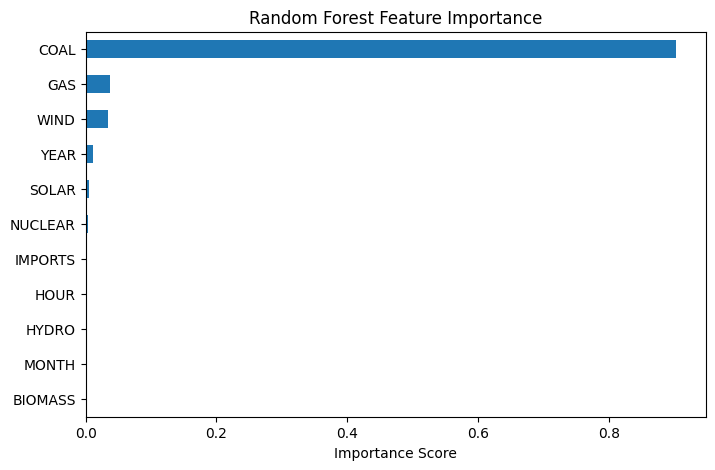

In [28]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")

plt.show()

In [29]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

COAL       0.902730
GAS        0.037046
WIND       0.034630
YEAR       0.011965
SOLAR      0.005094
NUCLEAR    0.003928
IMPORTS    0.001628
HOUR       0.001548
HYDRO      0.000920
MONTH      0.000368
BIOMASS    0.000144
dtype: float64


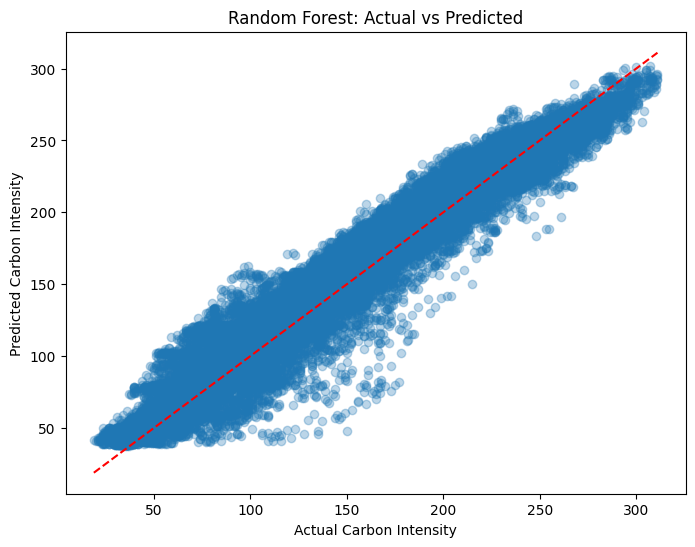

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Carbon Intensity")
plt.ylabel("Predicted Carbon Intensity")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

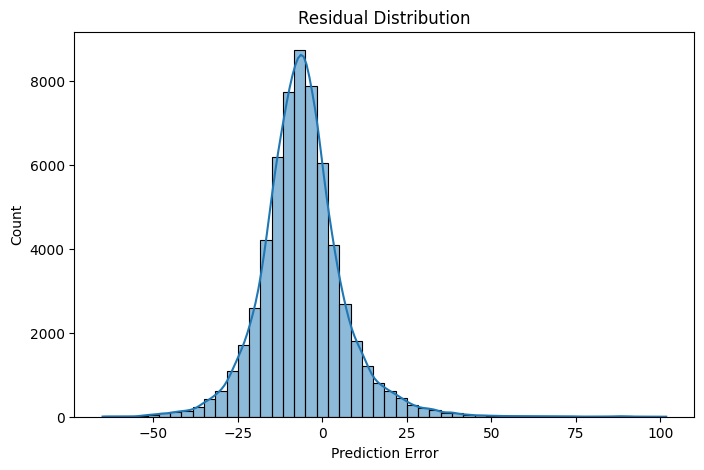

In [31]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")

plt.show()

Feature importance analysis revealed that coal generation was the dominant predictor of carbon intensity. This reflects the historical role of coal as the most carbon-intensive fuel source within the UK electricity system. As coal generation declined over the study period, carbon intensity also decreased substantially. Gas and wind generation provided additional predictive value, while other generation sources had comparatively smaller contributions.

This study analysed the evolution of the UK electricity system between 2009 and 2026. Results showed a substantial decline in coal generation alongside rapid growth in wind and other renewable energy sources. These changes coincided with a significant reduction in carbon intensity, indicating progress towards a lower-carbon electricity system.

Machine learning models were then developed to predict carbon intensity from electricity generation sources. The Random Forest model achieved the strongest performance (R² = 0.952, MAE = 10.55), demonstrating that generation mix is highly predictive of carbon intensity. Feature importance analysis identified coal generation as the dominant driver of carbon intensity, highlighting its historical role in UK electricity sector emissions.